<a href="https://colab.research.google.com/github/shivamkumar359/3rd-SEM-CLASS-CODES/blob/main/ML/W5__WEEK_5_PRACTICAL_SESSION_BY_MITHUN_DJ_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# RANDOM FOREST & BAGGING
# "FOREST POWER"
# ============================================================
# ============================================================
# PART 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ============================================================
# PART 2: LOAD DATASET
# ============================================================
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y = data.target

print("Dataset Shape:", X.shape)

print("\nFirst 5 Rows:")
display(X.head())

print("\nTarget Classes:")
print(data.target_names)

Dataset Shape: (569, 30)

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Classes:
['malignant' 'benign']


In [ ]:
# ============================================================
# PART 3: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


In [ ]:
# ============================================================
# PART 4: ONE DECISION TREE
# ============================================================

tree = DecisionTreeClassifier(
    random_state=42
)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)
print("\n1 Decision Tree Accuracy:",
      round(tree_accuracy, 4))



1 Decision Tree Accuracy: 0.9123


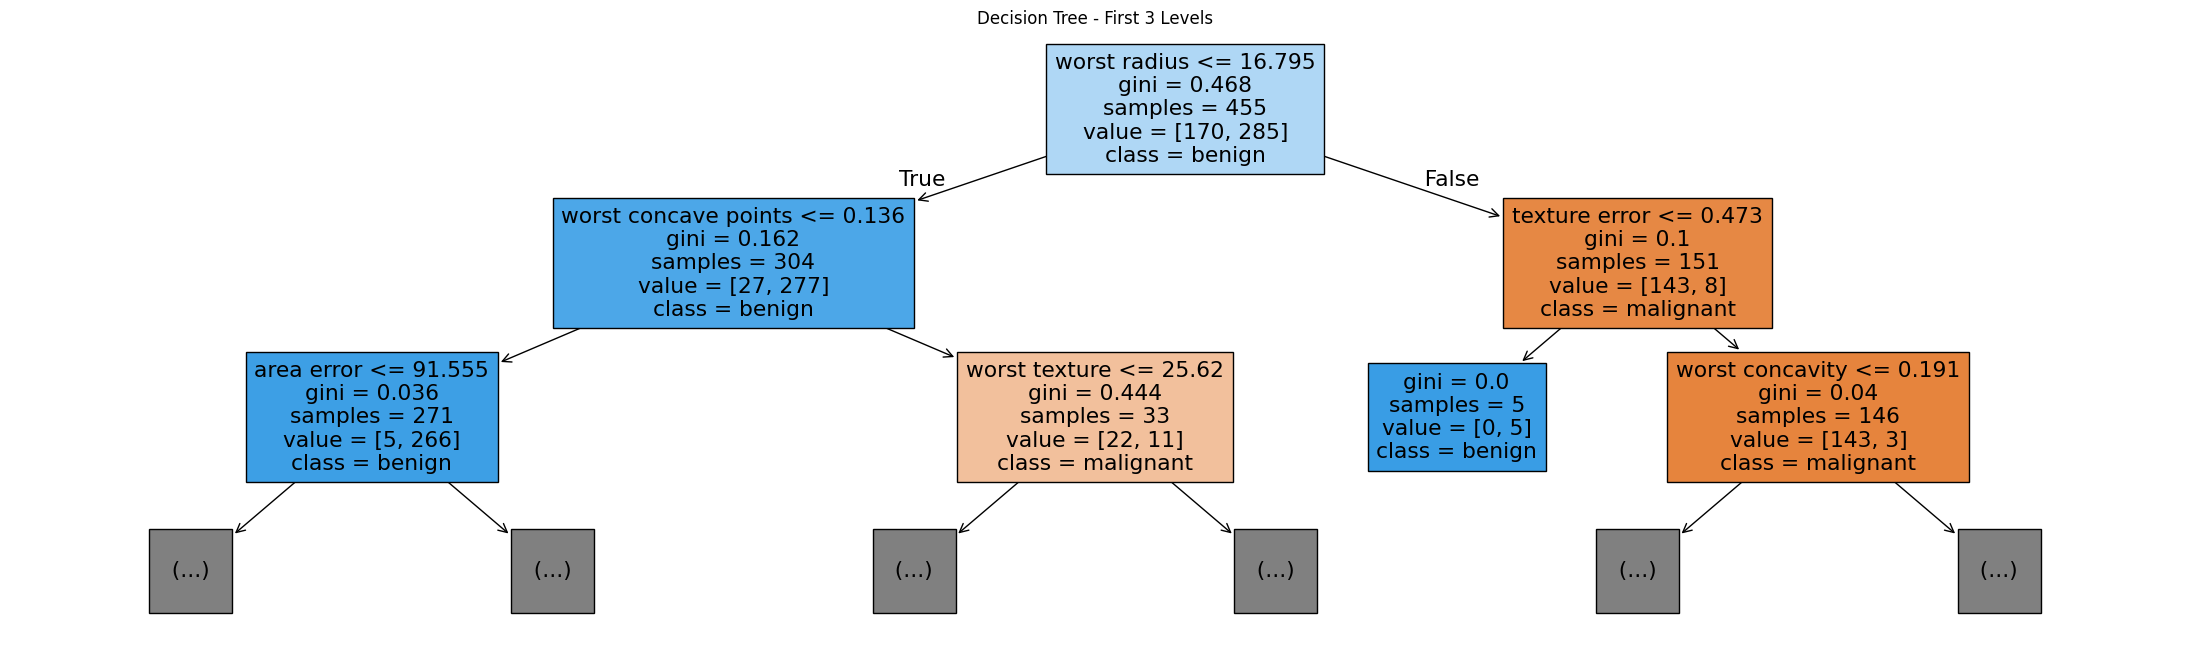

In [ ]:
# ============================================================
# PART 5: VISUALIZE DECISION TREE
# ============================================================
plt.figure(figsize=(28, 8))
plot_tree(
    tree,
    max_depth=2,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True
)
plt.title("Decision Tree - First 3 Levels")
plt.show()

In [ ]:
# ============================================================
# PART 6: BAGGING
# ============================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [ ]:
y_pred_bagging = bagging.predict(X_test)
y_pred_bagging

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [ ]:
bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)
bagging_accuracy

0.9385964912280702

In [ ]:
print("\n100 Bagging Trees Accuracy:",
      round(bagging_accuracy, 4))


100 Bagging Trees Accuracy: 0.9386


In [ ]:
# ============================================================
# PART 7: RANDOM FOREST - 100 TREES
# ============================================================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)
